# Food-Bank Inventory Management
**Stochastic Optimisation (2024-2025)**  
Author(s): Mael HAMET, Jean GOEPFERT, Yannis BENMANSOUR

In [1]:
import sys, subprocess, importlib.util, os, json, pathlib, platform

def pip_install(pkg):
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

pip_install("numpy")
pip_install("pandas")
pip_install("cvxpy")
pip_install("gurobipy")     

# 1.2  Activate GUROBI (one-time)

import os, pathlib
# absolute path to your file  (raw-string avoids issues with back-slashes)
os.environ["GRB_LICENSE_FILE"] = r"C:\Users\yanni\Desktop\ORRA\Stochastic Optimization\gurobi.lic"


try:
    import gurobipy as gp
    print("✔ Gurobi version:", gp.gurobi.version())
except gp.GurobiError as e:
    raise RuntimeError("Gurobi is not licensed – see the comment above.") from e


✔ Gurobi version: (12, 0, 1)


In [11]:
import numpy as np
import pandas as pd
import cvxpy as cv        
from pathlib import Path

# ================================================================
# PARAMETERS – copied from the template cell
# ================================================================

# ---------- 1. scalar costs ----------
c_o = np.array([20., 25.])   # ordering cost per warehouse (index 0,1)
c_w = 5.0                    # waste-disposal €/meal
c_h = 2.0                    # nightly holding €/meal (warehouse)

# ---------- 2. transportation cost warehouse -> district ----------
# D1[i,j] only defined for j in same service group as warehouse i
D1 = np.array([[5., 6., 5.],     # warehouse-1 to districts 1-3
               [5., 6., 5.]])    # warehouse-2 to districts 4-6
# Build full cf matrix 2×6; unreachable lanes = 0 cost (for clarity)
cf = np.zeros((2, 6))
cf[0, 0:3] = D1[0]        # wh-1 to d1-3
cf[1, 3:6] = D1[1]        # wh-2 to d4-6
print("cf (warehouse→district) =\n", cf)

# ---------- 3. emergency transfer cost between districts ----------
points = np.array([[ 6,  1],   # d1
                   [ 6, -1],   # d2
                   [ 8,  0],   # d3
                   [-6,  1],   # d4
                   [-6, -1],   # d5
                   [-8,  0]])  # d6
D2 = np.abs(points[:, None] - points[None, :]).sum(axis=2)
# Keep only intra-warehouse transfers (d1-3 between themselves; d4-6 likewise)
ce = np.zeros_like(D2)
ce[0:3, 0:3] = D2[0:3, 0:3]
ce[3:6, 3:6] = D2[3:6, 3:6]
print("ce (district→district) intra-warehouse distances:\n", ce)

# ---------- 4. Load training data ----------
Demand = np.zeros([52*5, 7, 1])
for j in range(1, 7):
    data = np.load(Path("Data") / f"{j}-training.npy")    # shape (5,52,7)
    Demand = np.concatenate((Demand, data.reshape(-1, 7, 1)), axis=2)
Demand = Demand[:, :, 1:]      # final shape (260, 7, 6)
print("Demand tensor shape:", Demand.shape)

# ---------- 5. Assign to symbols used later ----------
dem = Demand                   # our optimisation code expects the name 'dem'
co  = c_o
ch  = c_h
cw  = c_w

# Tensored versions for element-wise multiplication later
W, D, J, S = 2, 7, 6, dem.shape[0]
cf_tensor = np.tile(cf[:, None, :], (1, D, 1))          # (2,7,6)
ce_tensor = ce[np.newaxis, :, :, np.newaxis]            # (1,6,6,1)



cf (warehouse→district) =
 [[5. 6. 5. 0. 0. 0.]
 [0. 0. 0. 5. 6. 5.]]
ce (district→district) intra-warehouse distances:
 [[0 2 3 0 0 0]
 [2 0 3 0 0 0]
 [3 3 0 0 0 0]
 [0 0 0 0 2 3]
 [0 0 0 2 0 3]
 [0 0 0 3 3 0]]
Demand tensor shape: (260, 7, 6)


## 3 Mathematical formulation (static SAA, 2-stage)

### Sets  
| Symbol | Meaning |
|--------|---------|
| *I* = {1,2} | warehouses |
| *J* = {1,…,6} | districts; J₁ = {1,2,3}, J₂ = {4,5,6} |
| *D* = {1,…,7} | days in a week (1 = Mon … 7 = Sun) |
| *S* | sampled weeks (260 scenarios from 5 years × 52) |

### Parameters  
| Name | Unit | Comment |
|------|------|---------|
| \(c^o_i\) | €/meal | ordering cost (20, 25) |
| \(c^h\) | €/meal/night | warehouse holding (2) |
| \(c^w\) | €/meal | waste-disposal (5) |
| \(c^{f}_{i j}\) | €/meal | planned shipping cost (distance in *D1*) |
| \(c^{e}_{j j'}\) | €/meal | emergency re-allocation inside a warehouse (Manhattan distance in *D2*) |
| \(\xi^s_{d j}\) | meals | demand of scenario *s* |

### First-stage (here-and-now) decision variables  
| Symbol | Definition |
|--------|------------|
| \(x_i \ge 0\) | meals ordered for warehouse *i* on Sunday |
| \(y_{i d j}\ge0\) | meals **planned** to ship from *i* to district *j* on day *d* |
| \(m\in\mathbb R\) | Friday transfer (+ if 1 → 2, – if 2 → 1) |

Transfer bounds \( m \le 0.15\,x_1,\; m \ge -0.20\,x_2 \)

### Second-stage (per scenario *s*) recourse variables  
| Symbol | Definition |
|--------|------------|
| \(I^s_{i d}\ge0\) | warehouse inventory **at end of day d** |
| \(R^s_{d j}\ge0\) | surplus returned from district *j* at end of day d |
| \(U^s_{d j}\ge0\) | unmet demand (shortage) on day d |
| \(E^s_{d j j'}\ge0\) | emergency meals re-routed *d* from *j* → *j'* (only inside same warehouse group) |

### Flow constraints  
*Initial inventory*   \(I^s_{i 0}=x_i\)

*Warehouse balance (end of day d ≥ 1)*  
\[
I^s_{i d}=I^s_{i,d-1}-\sum_{j\in J_i} y_{i d j}
           + \mathbf 1_{\{d\ge5\}}\,(+m\text{ or }-m)_{i}
           + \sum_{j\in J_i} R^s_{d j}
\]

*District balance (during day d)* (for each \(j\in J\))  
\[
y_{i d j}+R^s_{d-1,j}
     +\sum_{j'}E^s_{d j' j}-\sum_{j'}E^s_{d j j'}
     =\xi^s_{d j}+R^s_{d j}+U^s_{d j},
\qquad i=\mathrm{owner}(j)
\]

*Emergency limits* \(E^s_{d j j'}=0\) if \(j\) and \(j'\) belong to different warehouses.

*Weekly service requirement*  
\[
\sum_{d} U^s_{d j}\;\le\;0.05\,\sum_{d}\xi^s_{d j}\quad\forall j,\;s.
\]

### Objective (minimise expected weekly cost)

\[
\min\;
\underbrace{\sum_{i} c^o_i\,x_i
+\sum_{i,d,j} c^f_{i j}\,y_{i d j}}_{\text{ordering + planned shipping}}
+\frac1{|S|}\sum_{s\in S}\Bigl[
  c^h\!\sum_{i,d\ge1} I^s_{i d}
 +c^w\!\sum_{j}R^s_{7 j}
 +\sum_{d,j,j'} c^{e}_{j j'}\,E^s_{d j j'}
\Bigr].
\]

This two-stage stochastic linear program is solved with **Sample Average Approximation** (|S| = 260) and Gurobi.


In [14]:
# ---------------------------------------------------------------
# Modelling with CVXPY  –  nightly returns go back to warehouse
# ---------------------------------------------------------------
import cvxpy as cv
W, D, J, S = 2, 7, 6, Demand.shape[0]
dem = Demand                              # alias used later

# ---- first-stage variables ----
x = cv.Variable(W, nonneg=True)           # Sunday orders
m = cv.Variable()                         # Friday transfer
y = cv.Variable((W, D, J), nonneg=True)   # planned day-d shipments

# ---- second-stage variables ----
I = cv.Variable((W, D+1, S), nonneg=True)         # warehouse inventory
R = cv.Variable((D, J,  S), nonneg=True)          # returned surplus
U = cv.Variable((D, J,  S), nonneg=True)          # shortages
E = cv.Variable((D, J,  J, S), nonneg=True)       # emergency moves

# ---- helper ----
def w_of(j):              # 0 for j=0-2, 1 for j=3-5
    return 0 if j < 3 else 1

# ---- constraints ----
cons = [ m <= 0.15*x[0],  m >= -0.20*x[1] ]

for s in range(S):
    cons += [ I[:,0,s] == x ]                       # Sunday night

    for d in range(1, D+1):
        ship = cv.sum(y[:,d-1,:], axis=1)           # day-d outbound
        transf = cv.hstack([-m, m]) if d >= 5 else cv.Constant([0,0])

        ret_today = cv.hstack([ cv.sum(R[d-1,0:3,s]),
                                cv.sum(R[d-1,3:6,s]) ])

        # warehouse balance (END of day d)
        cons += [ I[:,d,s] == I[:,d-1,s] - ship + transf + ret_today ]

        # district balance in day d
        for j in range(J):
            i = w_of(j)
            prev_ret = R[d-2, j, s] if d > 1 else 0
            cons += [
                y[i,d-1,j] + prev_ret
              + cv.sum(E[d-1,:,j,s]) - cv.sum(E[d-1,j,:,s])
              == dem[s,d-1,j] + R[d-1,j,s] + U[d-1,j,s]
            ]
            # forbid cross-warehouse emergency
            for j2 in range(J):
                if w_of(j2) != i:
                    cons += [E[d-1,j,j2,s] == 0]

    # weekly 95 % service
    total_week = dem[s,:,:].sum(axis=0)
    unmet_week = cv.sum(U[:,:,s], axis=0)
    cons += [ unmet_week <= 0.05*total_week ]

# ---- cost tensors ----
# shipping cost cf -> shape (2,7,6)
cf_full = np.zeros((2,6)); cf_full[0,:3] = D1[0]; cf_full[1,3:] = D1[1]
cf_tensor = np.tile(cf_full[:,None,:], (1,D,1))
ce_tensor = D2[np.newaxis,:,: ,np.newaxis]          # broadcast to (7,6,6,S)
ce_tensor[:,0:3,3:6,:] = 0                          # zero cross-warehouse lanes
ce_tensor[:,3:6,0:3,:] = 0

# ---- objective ----
ordering_cost   = c_o @ x
ship_cost       = cv.sum(cv.multiply(cf_tensor, y))
hold_cost       = c_h * cv.sum(I[:,1:,:])
waste_cost      = c_w * cv.sum(R[D-1,:,:])
emerg_cost      = cv.sum(cv.multiply(ce_tensor, E))

exp_second = (hold_cost + waste_cost + emerg_cost) / S
prob = cv.Problem(cv.Minimize(ordering_cost + ship_cost + exp_second), cons)

# ---- solve ----
try:
    prob.solve(solver="GUROBI", TimeLimit=600, verbose=False)
except Exception as e:
    print("Gurobi not available, using ECOS:", e)
    prob.solve(solver="ECOS", verbose=False)

print(f"Objective  : {prob.value:,.0f} € / week")
print(f"Service    : {1 - U.value.sum()/dem.sum():.3%}")
print(f"Waste ratio: {R.value[D-1,:,:].sum()/dem.sum():.3%}")


Objective  : 145,044 € / week
Service    : 95.043%
Waste ratio: 29.313%


In [16]:
print("Total shipments over a week:", y.value.sum())
print("Service ratio =", 1 - U.value.sum()/dem.sum())
print("Waste ratio   =", R.value[D-1,:,:].sum()/dem.sum())


Total shipments over a week: 15801.650000000001
Service ratio = 0.9504274060552
Waste ratio   = 0.29313015360999034


In [17]:
import json
import pandas as pd
from pathlib import Path

# ensure RESULT_DIR matches your folder
RESULT_DIR = Path("result")
RESULT_DIR.mkdir(exist_ok=True)

# 1) Extract first‐stage decisions
first_stage = {
    "x": x.value.tolist(),           # inventory per warehouse
    "m": float(m.value),             # Friday transfer
    "y": y.value.tolist()            # planned shipments
}

with open(RESULT_DIR/"first_stage.json", "w") as f:
    json.dump(first_stage, f, indent=2)

# 2) Compute KPIs
total_demand = dem.sum()
service_ratio = 1 - U.value.sum() / total_demand
waste_ratio   = R.value[D-1,:,:].sum() / total_demand

kpi = pd.DataFrame([{
    "objective": prob.value,
    "service"  : service_ratio,
    "waste"    : waste_ratio
}])

kpi.to_csv(RESULT_DIR/"kpi.csv", index=False)

print(f"Saved first_stage.json and kpi.csv in `{RESULT_DIR}`")


Saved first_stage.json and kpi.csv in `result`


Demand.shape: (260, 7, 6)


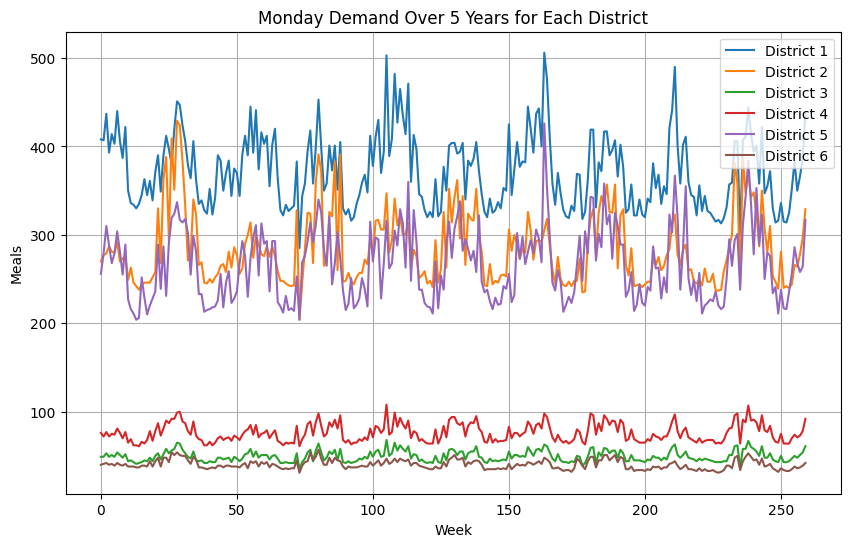

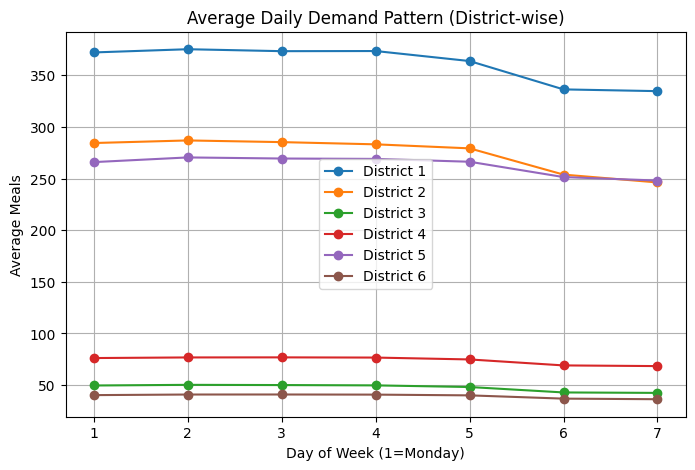

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. Load all six district demand files ===
DATA_DIR = "Data"   # adjust if needed
demand_list = []
for j in range(1, 7):
    arr = np.load(f"{DATA_DIR}/{j}-training.npy")  # shape (5,52,7)
    arr = arr.reshape(-1, 7)                        # reshape to (260,7)
    demand_list.append(arr)

# Stack into (260, 7, 6)
Demand = np.stack(demand_list, axis=2)   # axes: (week, day, district)

print("Demand.shape:", Demand.shape)  # should be (260, 7, 6)

# === 2. Plot Monday demand across weeks for each district ===
plt.figure(figsize=(10,6))
for j in range(6):
    plt.plot(Demand[:, 0, j], label=f"District {j+1}")
plt.title("Monday Demand Over 5 Years for Each District")
plt.xlabel("Week")
plt.ylabel("Meals")
plt.legend()
plt.grid(True)
plt.show()

# === 3. Plot average daily demand pattern for each district ===
avg_daily_demand = Demand.mean(axis=0)  # average over weeks -> shape (7 days, 6 districts)

plt.figure(figsize=(8,5))
for j in range(6):
    plt.plot(range(1,8), avg_daily_demand[:,j], marker='o', label=f"District {j+1}")
plt.title("Average Daily Demand Pattern (District-wise)")
plt.xlabel("Day of Week (1=Monday)")
plt.ylabel("Average Meals")
plt.legend()
plt.grid(True)
plt.show()


# This is markdown block
### Please explain your methodology for constructing the policy for task 2.
### Please save your decisions to the ./result directory
### check the following examples.

In [ ]:
# Here you can define your policy
# this function is a demo, you dont need to follow it.
def Dynamic_Policy(index_of_week, Hist_Demand, ParamPolicy):
    '''
    index_of_week: the index of week of interest
    Hist_Demand: the historical demand the policy needs
    ParamPolicy: the parameters of the policy
    '''
    # Grab the data
    return [x,y,m]


In [ ]:
# here you can save your decision result
# assume x, y, and m are solved for 10th week. you can save it like this
x = np.zeros(2)
y = np.zeros([7, 6]) # 
m = np.zeros(1)
np.save("./result/week10_x.npy", x.reshape([2,1]))
np.save("./result/week10_y.npy", y.reshape([7,6]))
np.save("./result/week10_m.npy", m.reshape([1,1]))
# for week 25, change week10_x to week25_x.
# Please, don't just submit zero to me.